In [2]:
# coding: utf-8
# наше всё
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from pylab import rcParams

# настройки pandas, с которыми лучше почти всегда
pd.set_option('display.max_rows', 45000)
pd.set_option('display.max_columns', 50000)
pd.set_option('display.max_colwidth', 5000)

# графики в svg выглядят более четкими
%config InlineBackend.figure_format = 'svg' 
rcParams['figure.figsize'] = 16, 12

In [3]:
source_df = pd.read_excel('qval5.xlsx', sheet_name='Worksheet')

In [4]:
res_df = source_df.copy()
diff_df = res_df.copy()
for i in range(1, len(diff_df.columns)-2):
    diff_df[i] = np.sum(diff_df[i]) / len(diff_df[i])



pot_df = res_df.copy()
for i in range(1, len(diff_df.columns)-2):
    pot_df[i] = diff_df[i] * res_df[i]


diff_df = diff_df[0:1][diff_df.columns[3:]].T
diff_df = diff_df.reset_index()
diff_df.columns = ['question', 'difficulty']


In [5]:
diff_df.sample(3)

,question,difficulty
17,18,0.372093
33,34,0.511628
3,4,0.558140


In [6]:
diff_df.sort_values(by='difficulty', ascending=False)[0:3]

,question,difficulty
24,25,0.930233
25,26,0.883721
13,14,0.837209


In [7]:
diff_df.sort_values(by='difficulty', ascending=True)[0:3]

,question,difficulty
26,27,0.046512
19,20,0.186047
15,16,0.209302


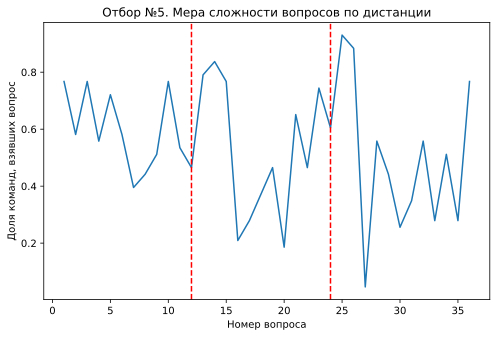

In [8]:
plt.figure(figsize=(8, 5))
sns.lineplot(data=diff_df, x='question', y='difficulty')
plt.xlabel('Номер вопроса')
plt.ylabel('Доля команд, взявших вопрос')
plt.title('Отбор №5. Мера сложности вопросов по дистанции')
#  вертикальная линия при x = 12 и x = 24
plt.axvline(x=12, color='red', linestyle='--')
plt.axvline(x=24, color='red', linestyle='--')
plt.show()


<Figure size 800x500 with 0 Axes>

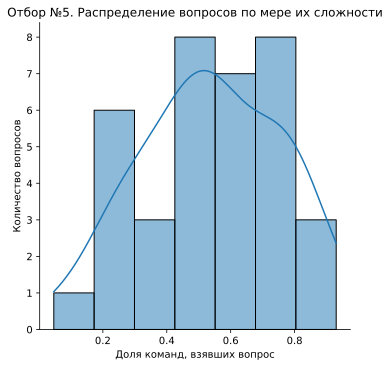

In [9]:
plt.figure(figsize=(8, 5))
sns.displot(diff_df['difficulty'], kde=True)
plt.xlabel('Доля команд, взявших вопрос')
plt.ylabel('Количество вопросов')
plt.title('Отбор №5. Распределение вопросов по мере их сложности')
plt.show()






In [10]:
team_stat = res_df[res_df.columns[0:3]].copy()
team_stat['result'] = np.sum(res_df[res_df.columns[3:]], axis=1)
team_stat['difficulty'] = np.sum(pot_df[pot_df.columns[3:]], axis=1)
team_stat['potential'] = team_stat['difficulty'] / team_stat['result']


In [11]:
team_stat.sort_values(by='result', ascending=False)

,Team ID,Название,Город,result,difficulty,potential
28,75592,Ленивые Лемминги,Москва,35,19.279070,0.550831
2,100000,Олд Мани,Москва,34,18.093023,0.532148
27,92044,Войско Тимура,Москва,33,18.744186,0.568006
17,100108,Плотнейший прогрев Борисова,Москва,31,17.720930,0.571643
29,46550,Ханаанский бальзам,Москва,30,17.418605,0.580620
8,13,Дельта фи,Москва,29,16.651163,0.574178
4,0,Жижка Жижека,Москва,28,16.674419,0.595515
7,80681,Останочки остаточков,Москва,27,16.093023,0.596038
38,0,НЕ НЕ ОКДФ,Москва,27,16.790698,0.621878
19,68169,Эксперты Мозгового Штурма,Москва,27,16.651163,0.616710


In [12]:
team_stat[['result']].describe()

,result
count,43.000000
mean,19.325581
std,8.219376
min,6.000000
25%,11.500000
50%,19.000000
75%,26.500000
max,35.000000


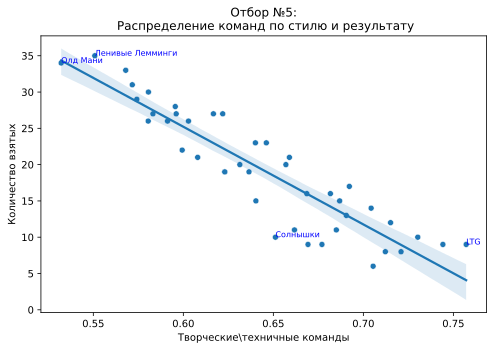

In [32]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=team_stat, 
    x="potential", 
    y="result",
    )

plt.title("Отбор №5:\n Распределение команд по стилю и результату")
# add a trend line
sns.regplot(data=team_stat, x="potential", y="result", scatter=False)

# add points
x1 = np.min(team_stat['potential'])
y1 = team_stat[team_stat['potential'] == x1]['result'].values[0]
name1 = team_stat[team_stat['potential'] == x1]['Название'].values[0]
plt.text(x1, y1, name1, fontsize=8, color='blue')

x2 = np.max(team_stat['potential'])
y2 = team_stat[team_stat['potential'] == x2]['result'].values[0]
name2 = team_stat[team_stat['potential'] == x2]['Название'].values[0]
plt.text(x2, y2, name2, fontsize=8, color='blue')

y3 = np.max(team_stat['result'])
x3 = team_stat[team_stat['result'] == y3]['potential'].values[0]
name3 = team_stat[team_stat['result'] == y3]['Название'].values[0]
plt.text(x3, y3, name3, fontsize=8, color='blue')

# y4 = np.min(team_stat['result'])
# x4 = team_stat[team_stat['result'] == y4]['potential'].values[0]
# name4 = team_stat[team_stat['result'] == y4]['Название'].values[0]
# plt.text(x4, y4, name4, fontsize=8, color='blue')

x5 = team_stat['potential'].values[np.random.randint(0, len(team_stat))]
y5 = team_stat[team_stat['potential'] == x5]['result'].values[0]
name5 = team_stat[team_stat['potential'] == x5]['Название'].values[0]
plt.text(x5, y5, name5, fontsize=8, color='blue')

plt.xlabel("Творческие\техничные команды")
plt.ylabel("Количество взятых")

plt.show()


In [14]:
# сильные техничные команды
team_stat[
    (team_stat['potential'] > np.mean(team_stat['potential'])) & 
    (team_stat['result'] > np.mean(team_stat['result']))
]['Название']

3      Сливочный кит
5     Весёлый тандем
14     Копнем глубже
Name: Название, dtype: object

In [15]:
# сильные творческие команды
team_stat[
    (team_stat['potential'] < np.mean(team_stat['potential'])) & 
    (team_stat['result'] > np.mean(team_stat['result']))
]['Название']

2                        Олд Мани
4                    Жижка Жижека
7            Останочки остаточков
8                       Дельта фи
9                  Колумбово яйцо
12               Живучка ползучая
16                          Швепс
17    Плотнейший прогрев Борисова
18                 Армия МурАвьев
19      Эксперты Мозгового Штурма
21                        Биолухи
27                  Войско Тимура
28               Ленивые Лемминги
29             Ханаанский бальзам
30                   Гланды панды
35           Тета Каппа Дельта Фи
38                     НЕ НЕ ОКДФ
42        Синдром Ли-Джима-Иейтса
Name: Название, dtype: object

In [16]:
team_stat.sort_values(by='potential', ascending=True)[0:5]

,Team ID,Название,Город,result,difficulty,potential
2,100000,Олд Мани,Москва,34,18.093023,0.532148
28,75592,Ленивые Лемминги,Москва,35,19.279070,0.550831
27,92044,Войско Тимура,Москва,33,18.744186,0.568006
17,100108,Плотнейший прогрев Борисова,Москва,31,17.720930,0.571643
8,13,Дельта фи,Москва,29,16.651163,0.574178


In [17]:
team_stat.sort_values(by='potential', ascending=False)[0:5]

,Team ID,Название,Город,result,difficulty,potential
31,0,LTG,Москва,9,6.813953,0.757106
32,0,Аааааа,Москва,9,6.697674,0.744186
36,104521,Сборная Каштанова,Москва,10,7.302326,0.730233
24,0,Когнитивный диссонанс,Москва,8,5.767442,0.720930
41,0,Баклажан наД АркОй,Москва,12,8.581395,0.715116


In [18]:
team_qv_df = res_df.melt(
    id_vars=['Название', 'Город', 'Team ID'],
    value_vars=res_df.columns[3:],
    var_name='question',
    value_name='qv_result'
)
team_qv_df = team_qv_df.merge(
    diff_df, 
    'left',
    on='question'
)
team_qv_df = team_qv_df.merge(
    team_stat,
    'left',
    on=['Название', 'Team ID', 'Город'],
    suffixes=('_qv', '_total')
)
team_qv_df['epic'] = team_qv_df['result'] * team_qv_df['difficulty_qv']




In [19]:
# топ эпических взятий
team_qv_df[team_qv_df['qv_result'] == 1].sort_values(by='epic', ascending=True)[0:3]

,Название,Город,Team ID,question,qv_result,difficulty_qv,result,difficulty_total,potential,epic
1132,Копнем глубже,Москва,0,27,1,0.046512,20,13.139535,0.656977,0.930233
1120,Олд Мани,Москва,100000,27,1,0.046512,34,18.093023,0.532148,1.581395
701,Солнышки,Москва,0,17,1,0.279070,10,6.511628,0.651163,2.790698


In [20]:
# топ эпических продолбов
team_qv_df[team_qv_df['qv_result'] == 0].sort_values(by='epic', ascending=False)[0:4]

,Название,Город,Team ID,question,qv_result,difficulty_qv,result,difficulty_total,potential,epic
189,Плотнейший прогрев Борисова,Москва,100108,5,0,0.720930,31,17.720930,0.571643,22.348837
610,Дельта фи,Москва,13,15,0,0.767442,29,16.651163,0.574178,22.255814
862,Олд Мани,Москва,100000,21,0,0.651163,34,18.093023,0.532148,22.139535
1067,Тета Каппа Дельта Фи,Москва,0,25,0,0.930233,22,13.186047,0.599366,20.465116


In [21]:
res_df = res_df.merge(
    team_stat,
    'left',
    on=['Название', 'Team ID', 'Город'],
    suffixes=('_qv', '_total')
)
res_df.sample(3)


,Team ID,Название,Город,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,result,difficulty,potential
21,102405,Биолухи,Москва,1,1,1,1,1,1,0,0,0,1,0,1,1,1,1,0,0,1,1,0,0,0,1,1,1,1,0,1,1,0,0,1,0,1,1,1,23,14.720930,0.640040
22,0,Орлеанские девы,Москва,1,0,1,1,1,0,0,1,0,1,1,0,1,1,0,0,1,0,0,0,1,0,0,0,1,1,0,0,1,0,0,1,0,0,0,1,16,10.697674,0.668605
25,0,Гном он,Москва,1,0,1,0,1,0,0,0,1,1,0,1,1,1,1,0,0,1,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,14,9.860465,0.704319


In [33]:
# корреляция между столбцам в data frame
correlations_with_result = pd.DataFrame(res_df[res_df.columns[3:-2]].corr()['result'])
correlations_with_result.columns = ['correlation']
correlations_with_result.sort_values(by='correlation', ascending=False)[0:40]

,correlation
result,1.000000
difficulty,0.991578
31,0.793601
19,0.777667
11,0.760582
29,0.679180
36,0.659067
22,0.657133
28,0.646736
6,0.625931


In [23]:
correlations_with_result.sort_values(by='correlation', ascending=True)[0:5]

,correlation
25,0.100879
15,0.171149
5,0.203650
27,0.208660
18,0.271210


In [24]:
res_df.sample(3)

,Team ID,Название,Город,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,result,difficulty,potential
15,104740,Ирис Кис-Кис,Москва,1,0,0,1,1,1,0,0,0,1,1,0,1,1,1,0,0,1,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,1,0,1,15,10.302326,0.686822
20,12101,Облепиха,Москва,1,0,1,1,0,0,0,1,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,9,6.093023,0.677003
31,0,LTG,Москва,0,0,0,1,1,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,9,6.813953,0.757106


In [25]:
top_3 = list(correlations_with_result.sort_values(by='correlation', ascending=False)[1:4].index)
top_5 = list(correlations_with_result.sort_values(by='correlation', ascending=False)[1:6].index)

In [26]:
res_df['top-3'] = np.sum(res_df[res_df.columns[res_df.columns.isin(top_3)]], axis=1)
res_df['top-5'] = np.sum(res_df[res_df.columns[res_df.columns.isin(top_5)]], axis=1)
res_df.sample(3)






,Team ID,Название,Город,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,result,difficulty,potential,top-3,top-5
28,75592,Ленивые Лемминги,Москва,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1,35,19.279070,0.550831,3,5
2,100000,Олд Мани,Москва,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,34,18.093023,0.532148,3,5
5,40361,Весёлый тандем,Москва,1,1,1,0,1,1,0,1,1,1,1,0,1,1,1,0,1,0,0,0,0,0,1,1,1,1,0,1,1,0,0,1,0,0,0,1,21,13.837209,0.658915,1,3


In [27]:
res_df[['top-3', 'top-5', 'result']].corr()

,top-3,top-5,result
top-3,1.000000,0.942664,0.899283
top-5,0.942664,1.000000,0.941074
result,0.899283,0.941074,1.000000
